In [1]:
import numpy as np
import os.path as osp
import uproot
import vector

import matplotlib
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
import utils # for plotting styles

/home/mdrnevich/dev/QuasiML_paper/QuasiML/SMEFT/../utils/__init__.py:5: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. 

  from . import plotting


In [2]:
source_path = "./data/SMEFT_SM_combined_tuple"
target_path = "./data/SMEFT_EFT_combined_tuple"
SAVE_DATA = True

## Load the data using Uproot

In [3]:
WEIGHT_NAME = "mcEventWeight"

data_arrays = []
for path in [source_path, target_path]:
    tree = uproot.open(path+".root")["Events"]
    keys = sorted(tree.keys())
    keys.remove(WEIGHT_NAME)
    
    arr = tree.arrays(library='np')
    arr = np.concatenate([arr[key] for key in keys], axis=1)
    arr = np.concatenate([arr, tree.arrays(WEIGHT_NAME, library='np')[WEIGHT_NAME]], axis=1)
    
    # ADD ANY CUTS
    njets_mask = arr[:, keys.index("Njets")] >= 1
    CUTS = njets_mask
    arr = arr[CUTS]

    # REMOVE ANY FEATURES NOT INCLUDED IN TRAINING OR FOR LATER FILTERING
    names = ["Njets"]
    for name in names:
        arr = np.delete(arr, keys.index(name), axis=1)
        keys.remove(name)
    data_arrays.append(arr)

source_array, target_array = data_arrays

In [4]:
print(source_array.shape, target_array.shape)
keys, len(keys)

(1332522, 21) (1244182, 21)


(['Jet_Eta',
  'Jet_Mass',
  'Jet_Phi',
  'Jet_Pt',
  'Muon_Eta0',
  'Muon_Eta1',
  'Muon_Eta2',
  'Muon_Eta3',
  'Muon_Mass0',
  'Muon_Mass1',
  'Muon_Mass2',
  'Muon_Mass3',
  'Muon_Phi0',
  'Muon_Phi1',
  'Muon_Phi2',
  'Muon_Phi3',
  'Muon_Pt0',
  'Muon_Pt1',
  'Muon_Pt2',
  'Muon_Pt3'],
 20)

## Create the Higgs 4 vector arrays

In [5]:
ZEROS = np.zeros_like(source_array[:, 0])
MUON_PT_IX = keys.index('Muon_Pt0')
MUON_ETA_IX = keys.index('Muon_Eta0')
MUON_PHI_IX = keys.index('Muon_Phi0')
MUON_M_IX = keys.index('Muon_Mass0')

source_HH_4vec = vector.array({"pt":ZEROS,"eta":ZEROS,"phi":ZEROS,"M":ZEROS})
for i in range(4):
    source_HH_4vec += vector.array({
        "pt": source_array[:, MUON_PT_IX+i],
        "eta": source_array[:, MUON_ETA_IX+i],
        "phi": source_array[:, MUON_PHI_IX+i],
        "M": source_array[:, MUON_M_IX+i]
    })

ZEROS = np.zeros_like(target_array[:, 0])
target_HH_4vec = vector.array({"pt":ZEROS,"eta":ZEROS,"phi":ZEROS,"M":ZEROS})
for i in range(4):
    target_HH_4vec += vector.array({
        "pt": target_array[:, MUON_PT_IX+i],
        "eta": target_array[:, MUON_ETA_IX+i],
        "phi": target_array[:, MUON_PHI_IX+i],
        "M": target_array[:, MUON_M_IX+i]
    })

## Look at some plots

Text(0.5, 1.0, 'Distribution of $m_{HH}$ for SM Data')

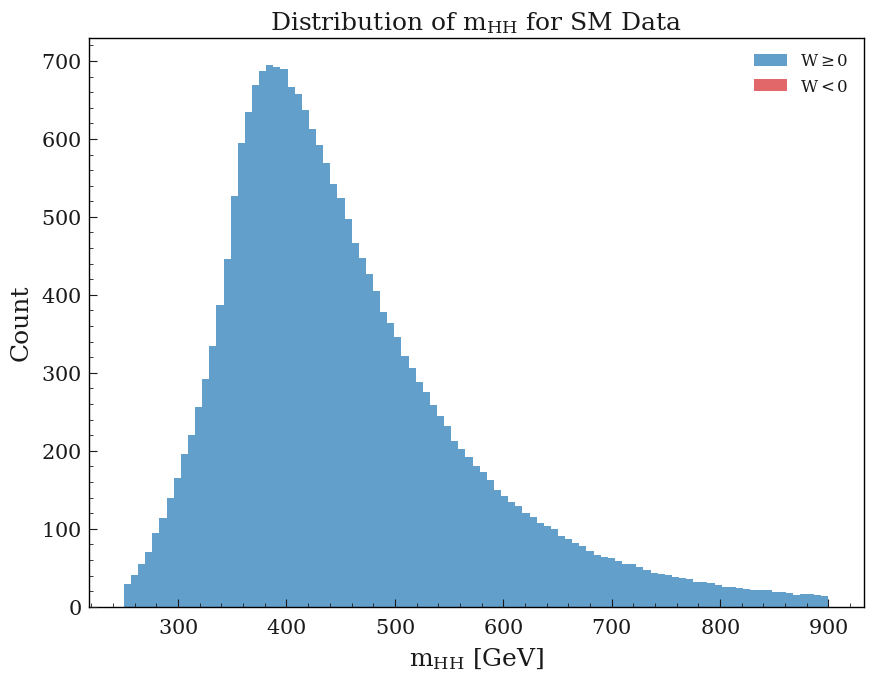

In [6]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

neg_mask = source_array[:,-1] < 0
pos_mask = ~neg_mask

bins = np.linspace(250, 900, 100)
ax.hist(source_HH_4vec.M[pos_mask], weights=source_array[:,-1][pos_mask], bins=bins,
        color='tab:blue', alpha=0.7, stacked=True, label=r"$W \geq 0$");
ax.hist(source_HH_4vec.M[neg_mask], weights=source_array[:,-1][neg_mask], bins=bins,
        color='tab:red', alpha=0.7, stacked=True, label=r"$W < 0$");
ax.set_xlabel(r"$m_{HH}$ [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of $m_{HH}$ for SM Data")

Text(0.5, 1.0, 'Distribution of $m_{HH}$ for SM+EFT Data')

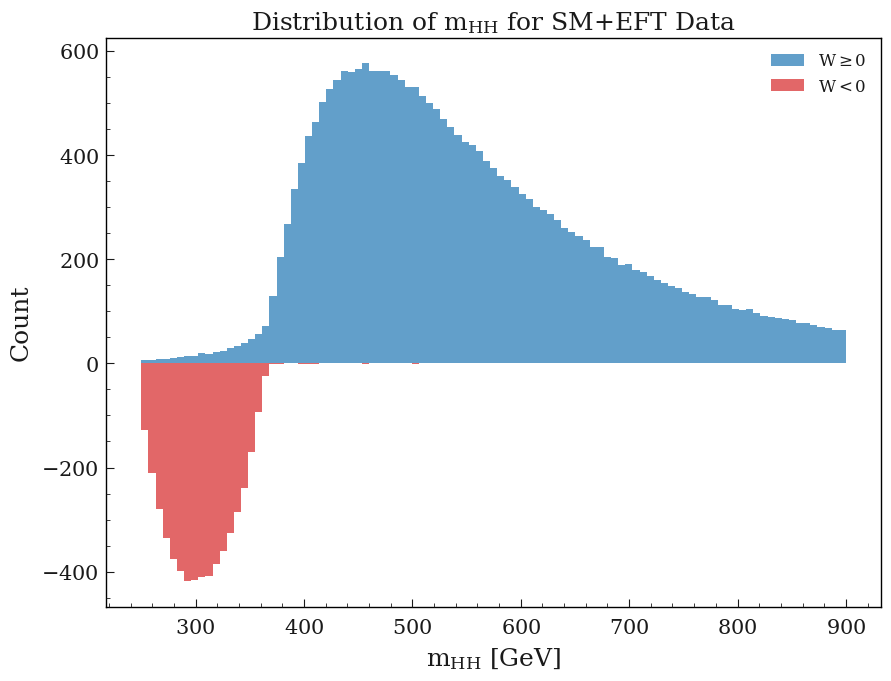

In [7]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

neg_mask = target_array[:,-1] < 0
pos_mask = ~neg_mask

bins = np.linspace(250, 900, 100)
ax.hist(target_HH_4vec.M[pos_mask], weights=target_array[:,-1][pos_mask], bins=bins,
        color='tab:blue', alpha=0.7, stacked=True, label=r"$W \geq 0$");
ax.hist(target_HH_4vec.M[neg_mask], weights=target_array[:,-1][neg_mask], bins=bins,
        color='tab:red', alpha=0.7, stacked=True, label=r"$W < 0$");
ax.set_xlabel(r"$m_{HH}$ [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of $m_{HH}$ for SM+EFT Data")

Text(0.5, 1.0, 'Distribution of $m_{HH}$ for Data')

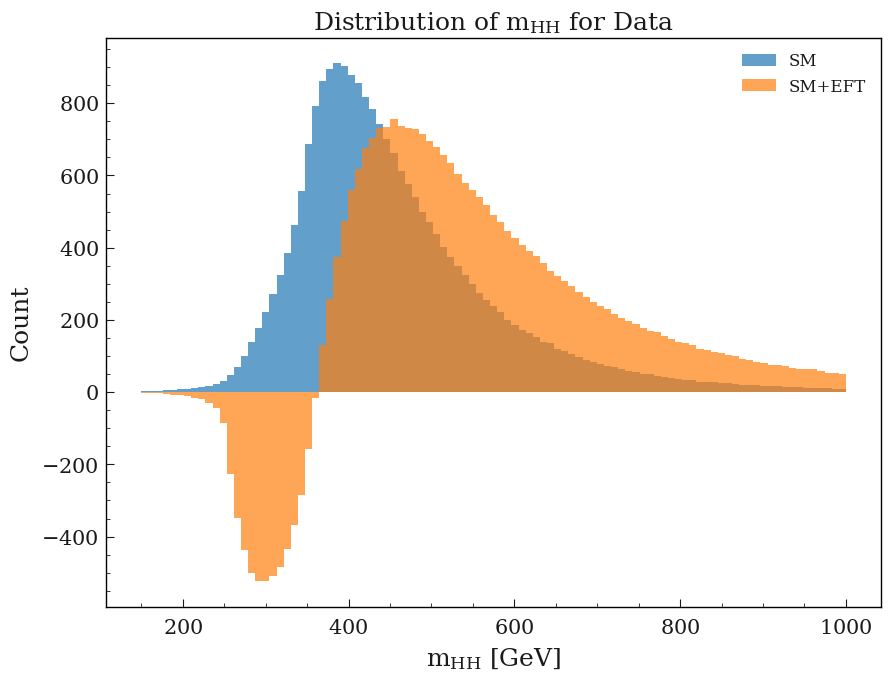

In [8]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

neg_mask = target_array[:,-1] < 0
pos_mask = ~neg_mask

bins = np.linspace(150, 1000, 100)
ax.hist(source_HH_4vec.M, weights=source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_HH_4vec.M, weights=target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT");
ax.set_xlabel(r"$m_{HH}$ [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of $m_{HH}$ for Data")

Text(0.5, 1.0, 'Distribution of Jet_Pt for Data')

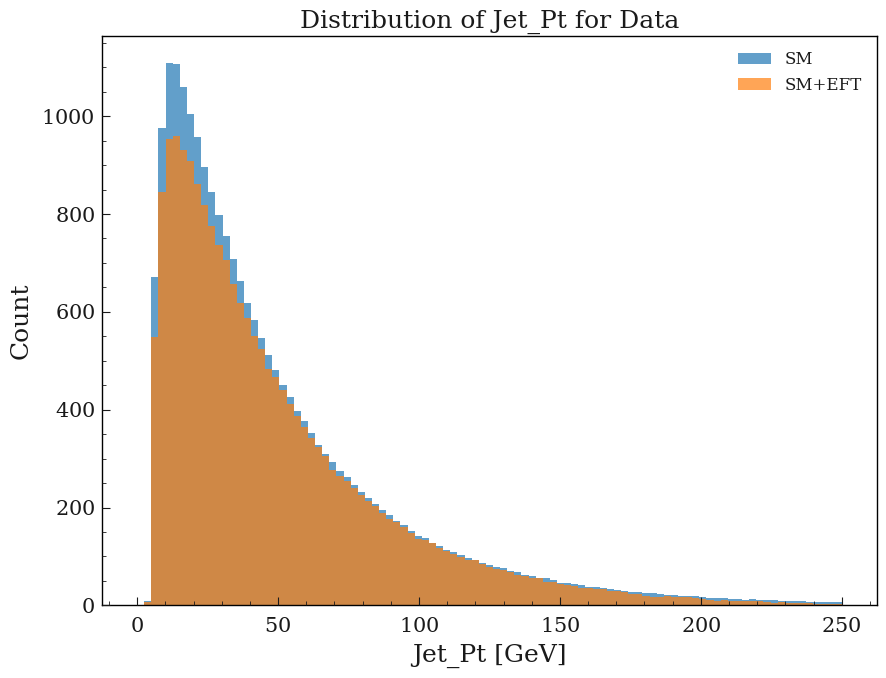

In [9]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])


bins = np.linspace(0, 250, 100)
ax.hist(source_array[:, keys.index('Jet_Pt')], weights=source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_array[:, keys.index('Jet_Pt')], weights=target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT");
ax.set_xlabel(r"Jet_Pt [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of Jet_Pt for Data")

Text(0.5, 1.0, 'Distribution of Muon_Pt0 for Data')

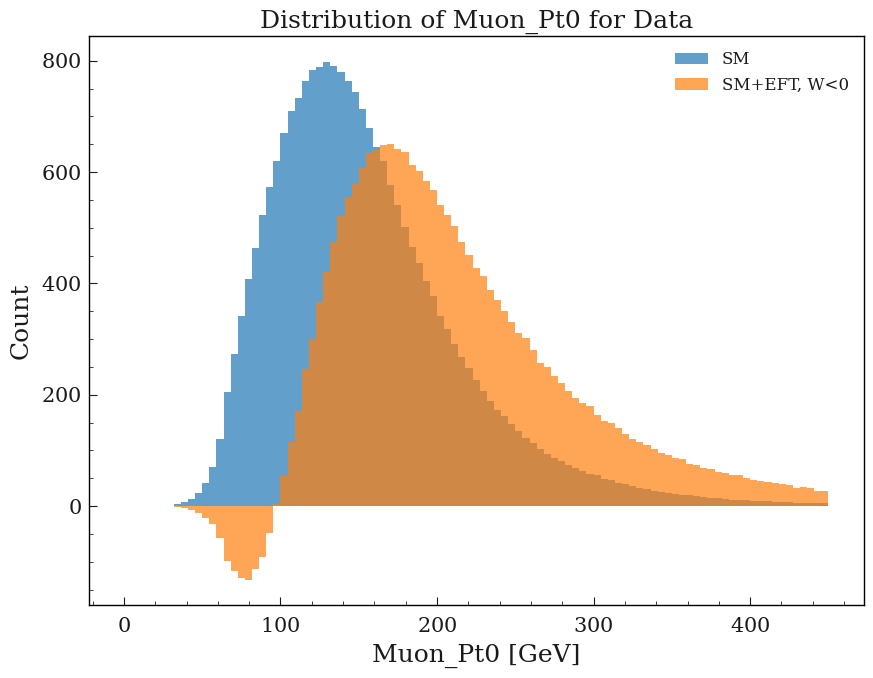

In [10]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])


bins = np.linspace(0, 450, 100)
ax.hist(source_array[:, keys.index('Muon_Pt0')], weights=source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_array[:, keys.index('Muon_Pt0')], weights=target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT, W<0");
ax.set_xlabel(r"Muon_Pt0 [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of Muon_Pt0 for Data")

Text(0.5, 1.0, 'Distribution of Muon_Pt1 for Data')

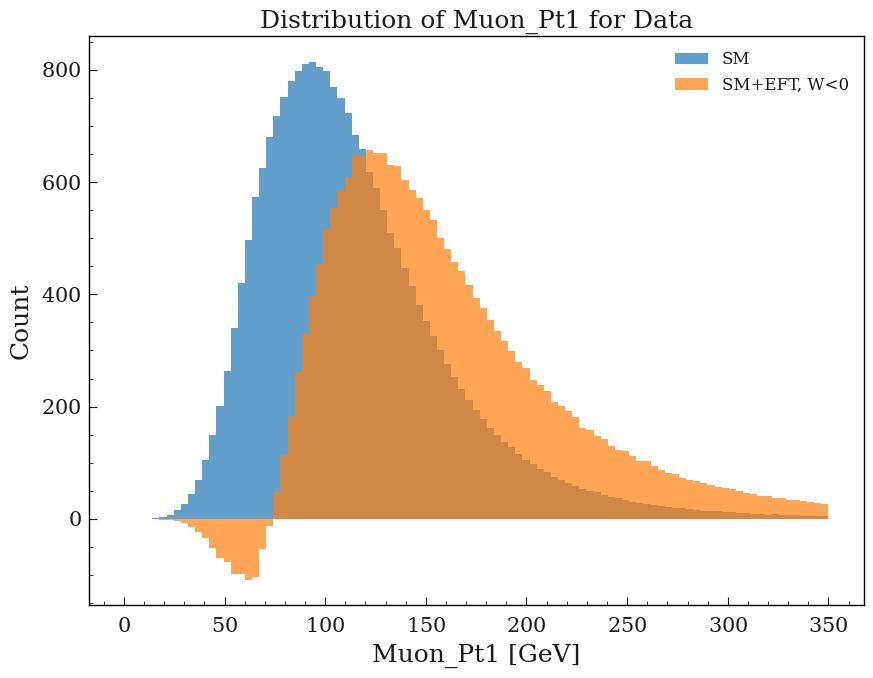

In [11]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

neg_mask = target_array[:,-1] < 0
pos_mask = ~neg_mask

bins = np.linspace(0, 350, 100)
ax.hist(source_array[:, keys.index('Muon_Pt1')], weights=source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_array[:, keys.index('Muon_Pt1')], weights=target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT, W<0");
ax.set_xlabel(r"Muon_Pt1 [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of Muon_Pt1 for Data")

Text(0.5, 1.0, 'Distribution of Muon_Pt2 for Data')

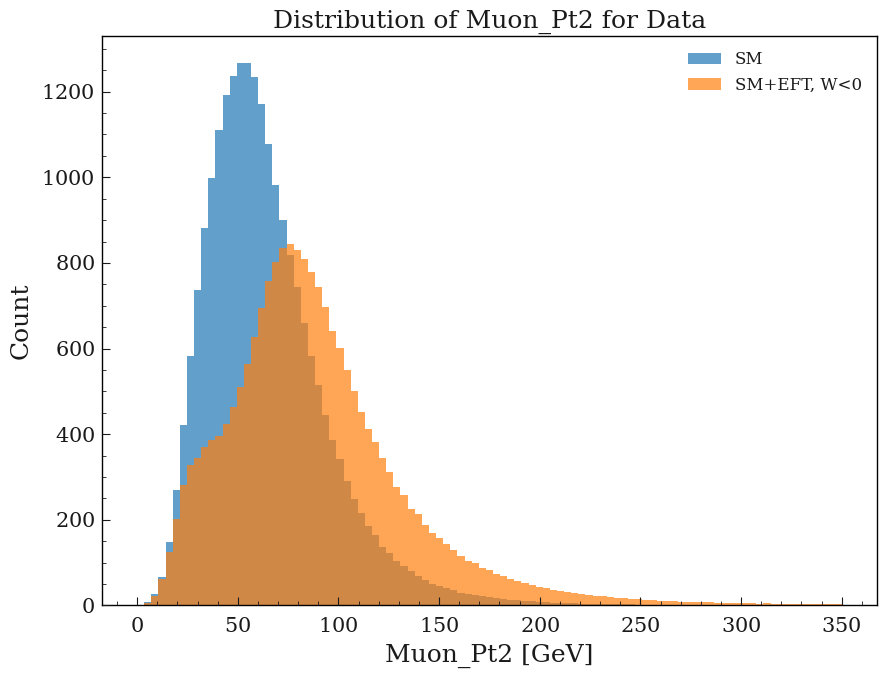

In [12]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

neg_mask = target_array[:,-1] < 0
pos_mask = ~neg_mask

bins = np.linspace(0, 350, 100)
ax.hist(source_array[:, keys.index('Muon_Pt2')], weights=source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_array[:, keys.index('Muon_Pt2')], weights=target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT, W<0");
ax.set_xlabel(r"Muon_Pt2 [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of Muon_Pt2 for Data")

Text(0.5, 1.0, 'Distribution of Muon_Pt3 for Data')

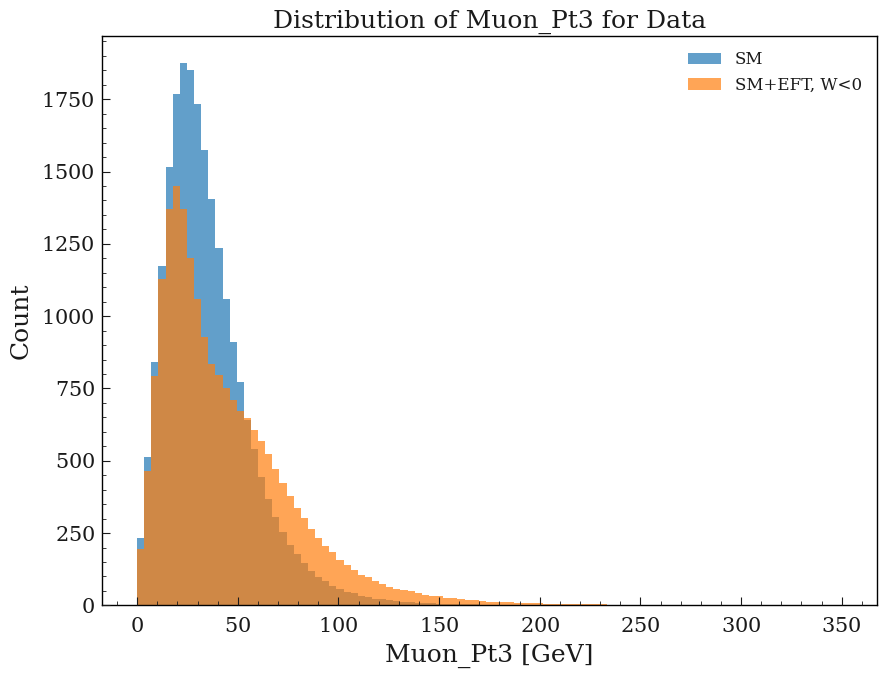

In [13]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

neg_mask = target_array[:,-1] < 0
pos_mask = ~neg_mask

bins = np.linspace(0, 350, 100)
ax.hist(source_array[:, keys.index('Muon_Pt3')], weights=source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_array[:, keys.index('Muon_Pt3')], weights=target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT, W<0");
ax.set_xlabel(r"Muon_Pt3 [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of Muon_Pt3 for Data")

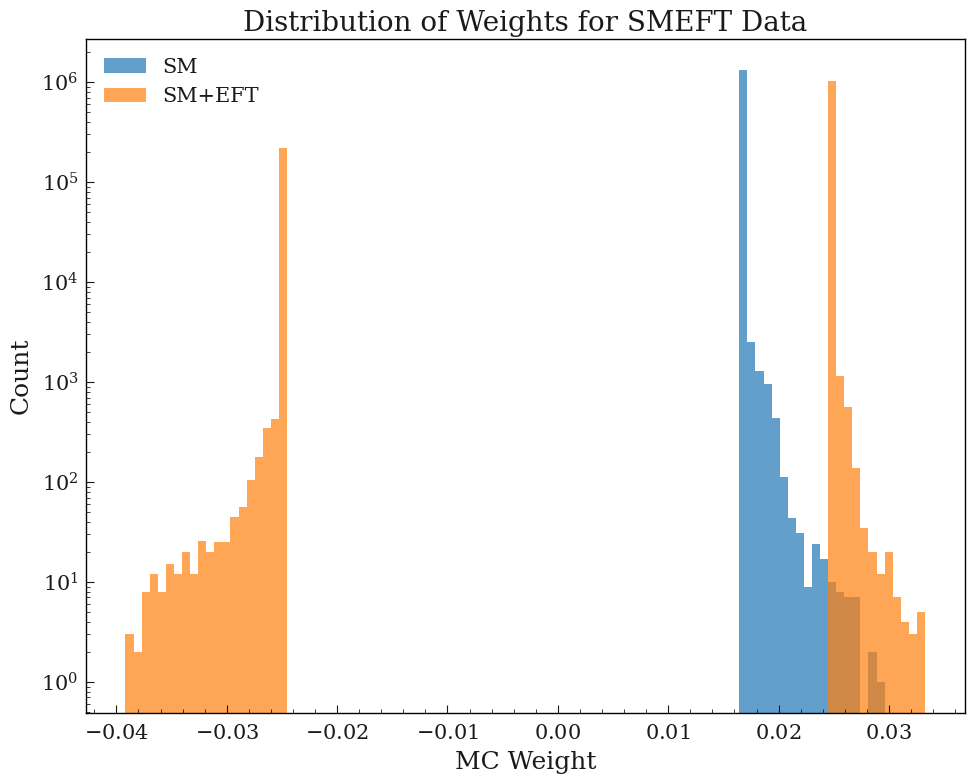

In [14]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

bins = np.linspace(np.min((source_array[:,-1].min(), target_array[:,-1].min())),
                   np.max((source_array[:,-1].max(), target_array[:,-1].max())),
                   100)
ax.hist(source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT");
ax.set_xlabel(r"MC Weight", size=18)
ax.set_ylabel("Count", size=18)
ax.set_yscale("log")
ax.legend(prop={'size': 15})
ax.set_title(r"Distribution of Weights for SMEFT Data", size=20)
fig.tight_layout()
#fig.savefig("SMEFT_weights.pdf")

# Now apply more cuts to the data

In [15]:
def get_HH_4vec(array, keys, nMuons=4):
    ZEROS = np.zeros_like(array[:, 0])
    MUON_PT_IX = keys.index('Muon_Pt0')
    MUON_ETA_IX = keys.index('Muon_Eta0')
    MUON_PHI_IX = keys.index('Muon_Phi0')
    
    HH_4vec = vector.array({"pt":ZEROS,"eta":ZEROS,"phi":ZEROS,"M":ZEROS})
    for i in range(nMuons):
        HH_4vec += vector.array({
            "pt": array[:, MUON_PT_IX+i],
            "eta": array[:, MUON_ETA_IX+i],
            "phi": array[:, MUON_PHI_IX+i],
            "M": np.ones_like(array[:, MUON_PT_IX+i])*0.10566001 #MUON MASS IS FIXED IN THIS DATA
        })
    return HH_4vec

In [16]:
WEIGHT_NAME = "mcEventWeight"


data_arrays = []
for path in [source_path, target_path]:
    tree = uproot.open(path+".root")["Events"]
    keys = sorted(tree.keys())
    keys.remove(WEIGHT_NAME)
    
    arr = tree.arrays(library='np')
    arr = np.concatenate([arr[key] for key in keys], axis=1)
    arr = np.concatenate([arr, tree.arrays(WEIGHT_NAME, library='np')[WEIGHT_NAME]], axis=1)
    print(arr.shape)
    
    # ADD ANY HARD CUTS FOR BOTH DATASETS
    CUTS = np.zeros_like(arr[:,0]) == 0
    HH_4vec = get_HH_4vec(arr, keys)
    masks = [arr[:, keys.index("Njets")] >= 1,
             arr[:, keys.index("Jet_Pt")] > 0,
             arr[:, keys.index("Jet_Mass")] > 0,
             arr[:, keys.index("Muon_Pt0")] > 0,
             arr[:, keys.index("Muon_Pt1")] > 0,
             arr[:, keys.index("Muon_Pt2")] > 0,
             arr[:, keys.index("Muon_Pt3")] > 0,
             
             abs(arr[:, keys.index("Jet_Eta")]) < 5,
             abs(arr[:, keys.index("Muon_Eta0")]) < 5,
             abs(arr[:, keys.index("Muon_Eta1")]) < 5,
             abs(arr[:, keys.index("Muon_Eta2")]) < 5,
             abs(arr[:, keys.index("Muon_Eta3")]) < 5,
            ]


    # MAKE CUTS
    for mask in masks:
        CUTS &= mask
    arr = arr[CUTS]

    # REMOVE ANY FEATURES NOT INCLUDED IN TRAINING
    names = ["Njets",]
    names += ["Muon_Mass0", "Muon_Mass1","Muon_Mass2", "Muon_Mass3"] # These are all fixed to 0.10566001
    for name in names:
        arr = np.delete(arr, keys.index(name), axis=1)
        keys.remove(name)
    data_arrays.append(arr)


# ADD MORE CUTS BASED ON THE REFERENCE DISTRIBUTION TO ENSURE SUPPORT
cut_percentile = 99.8
cuts = {
    "Jet_Pt": (0, np.percentile(data_arrays[0][:, keys.index("Jet_Pt")], cut_percentile)),
    "Muon_Pt0": (0, np.percentile(data_arrays[0][:, keys.index("Muon_Pt0")], cut_percentile)),
    "Muon_Pt1": (0, np.percentile(data_arrays[0][:, keys.index("Muon_Pt1")], cut_percentile)),
    "Muon_Pt2": (0, np.percentile(data_arrays[0][:, keys.index("Muon_Pt2")], cut_percentile)),
    "Muon_Pt3": (0, np.percentile(data_arrays[0][:, keys.index("Muon_Pt3")], cut_percentile)),
}


# APPLY THE CUTS
for i, arr in enumerate(data_arrays):
    # CUT LOW/HIGH VALUES
    mask = np.zeros(arr.shape[0]) == 0
    for name, (cut_low, cut_high) in cuts.items():
        print(name, (cut_low, cut_high), keys.index(name))
        mask &= (arr[:, keys.index(name)] >= cut_low) & (arr[:, keys.index(name)] <= cut_high)  # FOR CUTTING
    print(mask.shape, mask.sum()/len(mask))
    data_arrays[i] = arr[mask]


source_array, target_array = data_arrays

(1350000, 22)
(1260000, 22)
Jet_Pt (0, 318.2509333496096) 3
Muon_Pt0 (0, 506.56210131835985) 12
Muon_Pt1 (0, 395.1292500000005) 13
Muon_Pt2 (0, 224.94770727539068) 14
Muon_Pt3 (0, 152.93477001953138) 15
(1327165,) 0.9929006566628866
Jet_Pt (0, 318.2509333496096) 3
Muon_Pt0 (0, 506.56210131835985) 12
Muon_Pt1 (0, 395.1292500000005) 13
Muon_Pt2 (0, 224.94770727539068) 14
Muon_Pt3 (0, 152.93477001953138) 15
(1239575,) 0.9635681584414013


In [17]:
print(source_array.shape, target_array.shape)
keys, len(keys) # (1320016, 21) (1213490, 21)

(1317743, 17) (1194415, 17)


(['Jet_Eta',
  'Jet_Mass',
  'Jet_Phi',
  'Jet_Pt',
  'Muon_Eta0',
  'Muon_Eta1',
  'Muon_Eta2',
  'Muon_Eta3',
  'Muon_Phi0',
  'Muon_Phi1',
  'Muon_Phi2',
  'Muon_Phi3',
  'Muon_Pt0',
  'Muon_Pt1',
  'Muon_Pt2',
  'Muon_Pt3'],
 16)

### Get the Higgs 4 vectors

In [18]:
source_HH_4vec = get_HH_4vec(source_array, keys, nMuons=4)
target_HH_4vec = get_HH_4vec(target_array, keys, nMuons=4)

## Look at the same plots now after the cuts

Text(0.5, 1.0, 'Distribution of $m_{HH}$ for SM Data')

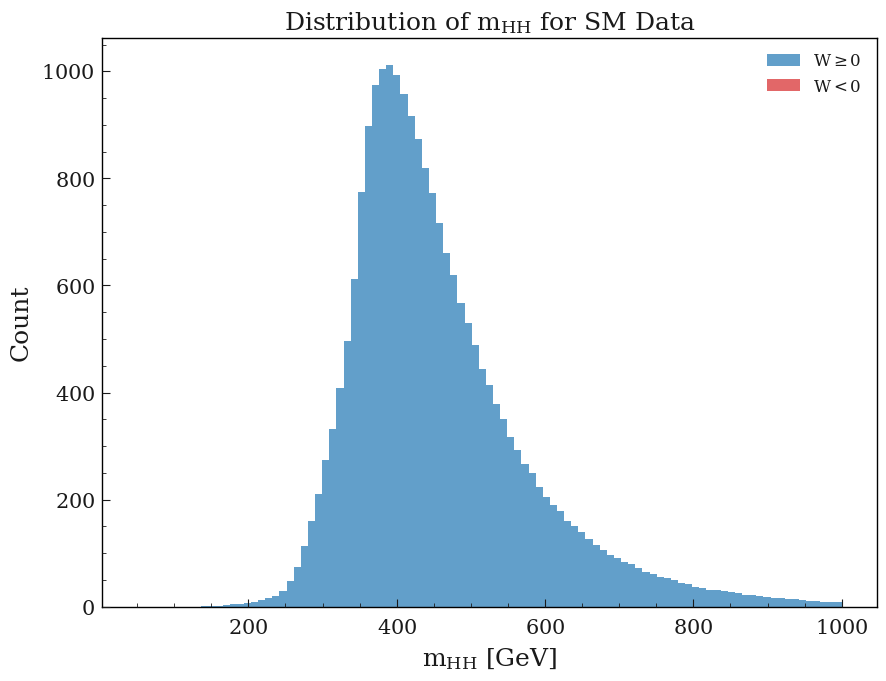

In [19]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

neg_mask = source_array[:,-1] < 0
pos_mask = ~neg_mask

bins = np.linspace(50, 1000, 100)
ax.hist(source_HH_4vec.M[pos_mask], weights=source_array[:,-1][pos_mask], bins=bins,
        color='tab:blue', alpha=0.7, stacked=True, label=r"$W \geq 0$");
ax.hist(source_HH_4vec.M[neg_mask], weights=source_array[:,-1][neg_mask], bins=bins,
        color='tab:red', alpha=0.7, stacked=True, label=r"$W < 0$");
ax.set_xlabel(r"$m_{HH}$ [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of $m_{HH}$ for SM Data")

Text(0.5, 1.0, 'Distribution of $m_{HH}$ for SM+EFT Data')

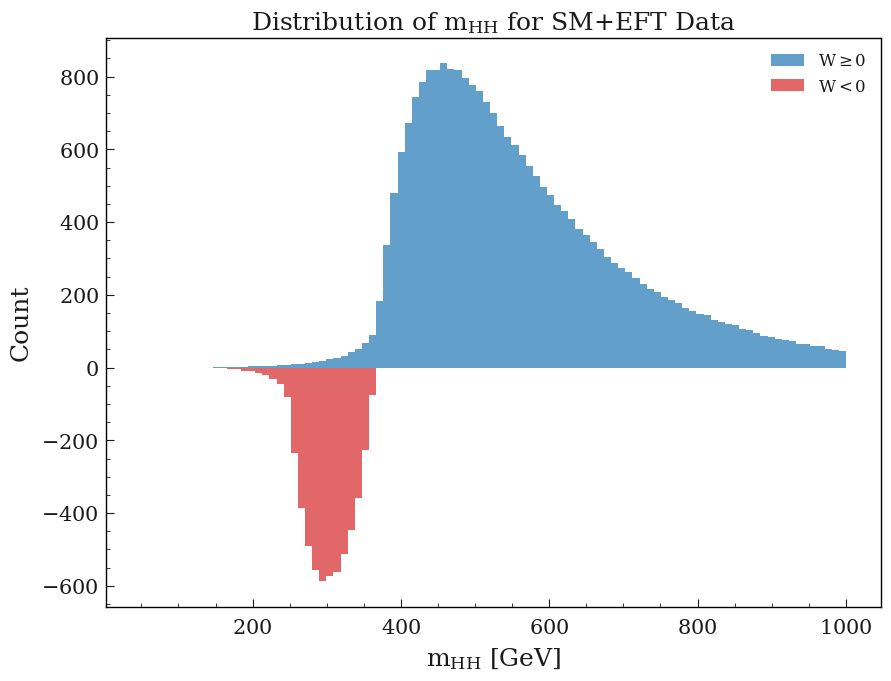

In [20]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

neg_mask = target_array[:,-1] < 0
pos_mask = ~neg_mask

bins = np.linspace(50, 1000, 100)
ax.hist(target_HH_4vec.M[pos_mask], weights=target_array[:,-1][pos_mask], bins=bins,
        color='tab:blue', alpha=0.7, stacked=True, label=r"$W \geq 0$");
ax.hist(target_HH_4vec.M[neg_mask], weights=target_array[:,-1][neg_mask], bins=bins,
        color='tab:red', alpha=0.7, stacked=True, label=r"$W < 0$");
ax.set_xlabel(r"$m_{HH}$ [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of $m_{HH}$ for SM+EFT Data")

Text(0.5, 1.0, 'Distribution of $m_{HH}$ for Data')

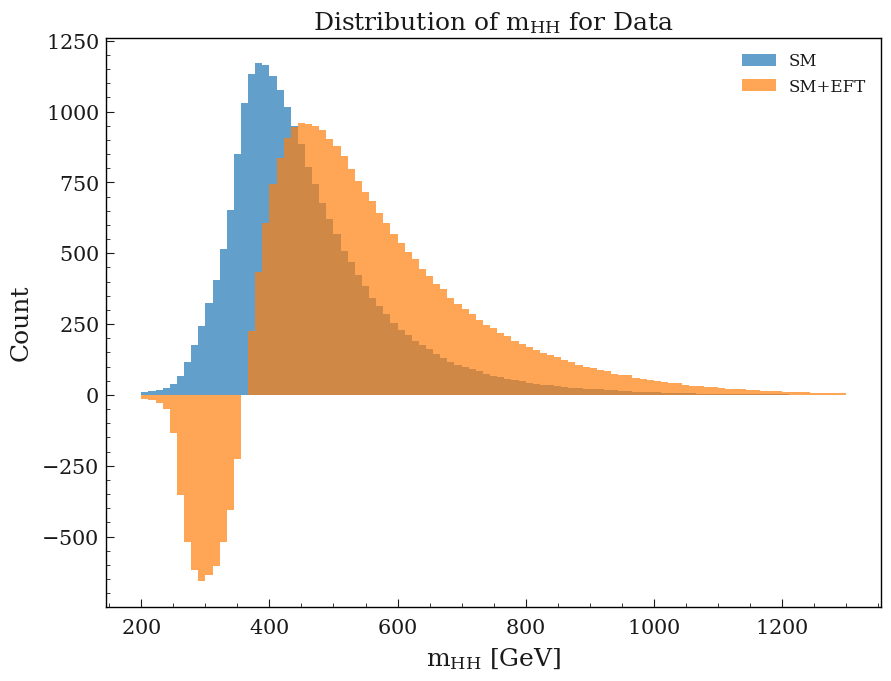

In [21]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

bins = np.linspace(200, 1300, 100)
ax.hist(source_HH_4vec.M, weights=source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_HH_4vec.M, weights=target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT");
ax.set_xlabel(r"$m_{HH}$ [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of $m_{HH}$ for Data")

506.54697 506.5306


Text(0.5, 1.0, 'Distribution of Muon_Pt0 for Data')

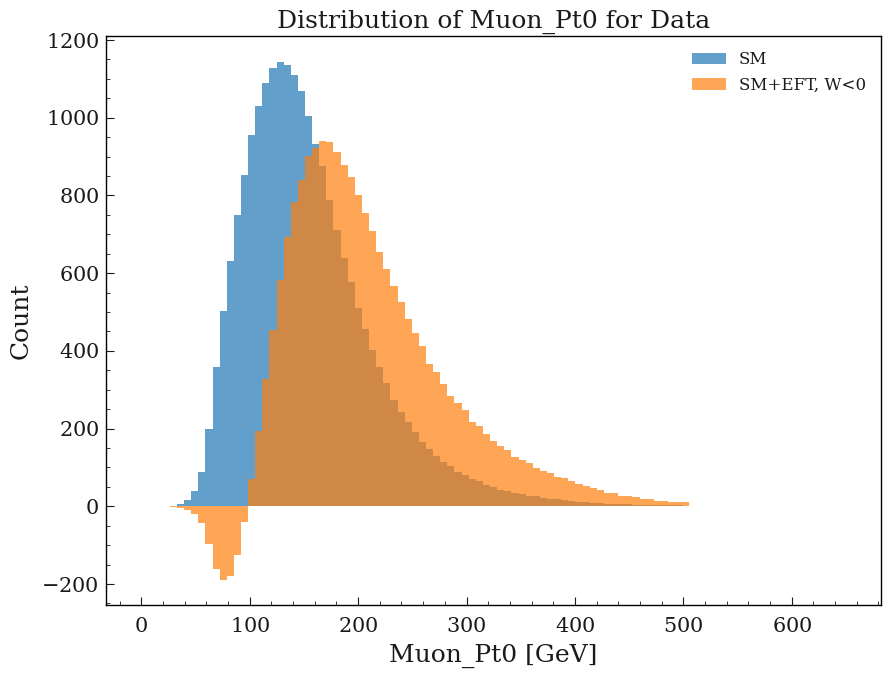

In [22]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

neg_mask = target_array[:,-1] < 0
pos_mask = ~neg_mask

print(source_array[:, keys.index('Muon_Pt0')].max(), target_array[:, keys.index('Muon_Pt0')].max())

bins = np.linspace(0, 650, 100)
ax.hist(source_array[:, keys.index('Muon_Pt0')], weights=source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_array[:, keys.index('Muon_Pt0')], weights=target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT, W<0");
ax.set_xlabel(r"Muon_Pt0 [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of Muon_Pt0 for Data")

Text(0.5, 1.0, 'Distribution of Muon_Pt1 for Data')

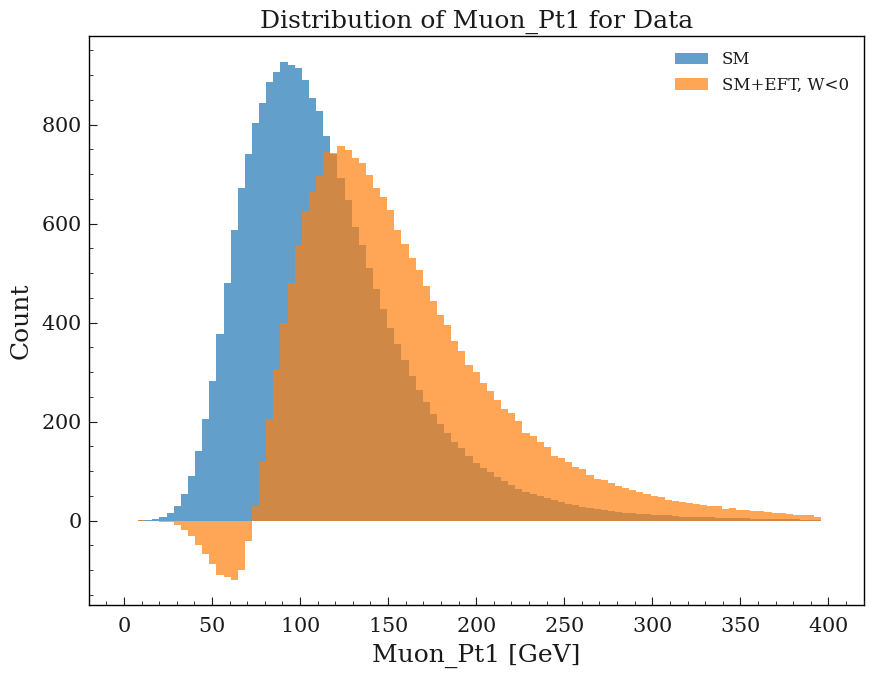

In [23]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

neg_mask = target_array[:,-1] < 0
pos_mask = ~neg_mask

bins = np.linspace(0, 400, 100)
ax.hist(source_array[:, keys.index('Muon_Pt1')], weights=source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_array[:, keys.index('Muon_Pt1')], weights=target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT, W<0");
ax.set_xlabel(r"Muon_Pt1 [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of Muon_Pt1 for Data")

Text(0.5, 1.0, 'Distribution of Muon_Pt2 for Data')

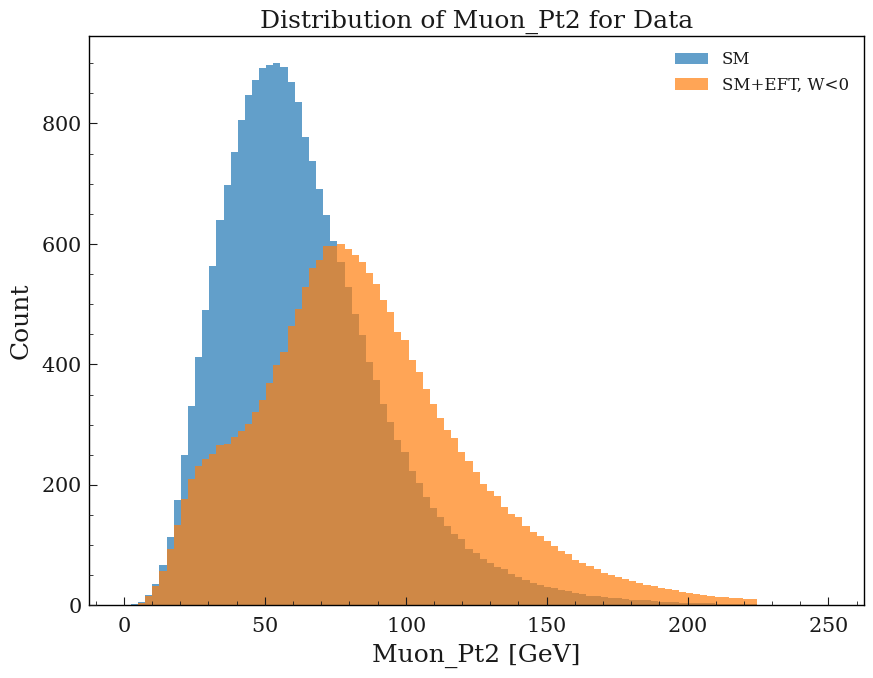

In [24]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

neg_mask = target_array[:,-1] < 0
pos_mask = ~neg_mask

bins = np.linspace(0, 250, 100)
ax.hist(source_array[:, keys.index('Muon_Pt2')], weights=source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_array[:, keys.index('Muon_Pt2')], weights=target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT, W<0");
ax.set_xlabel(r"Muon_Pt2 [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of Muon_Pt2 for Data")

Text(0.5, 1.0, 'Distribution of Muon_Pt3 for Data')

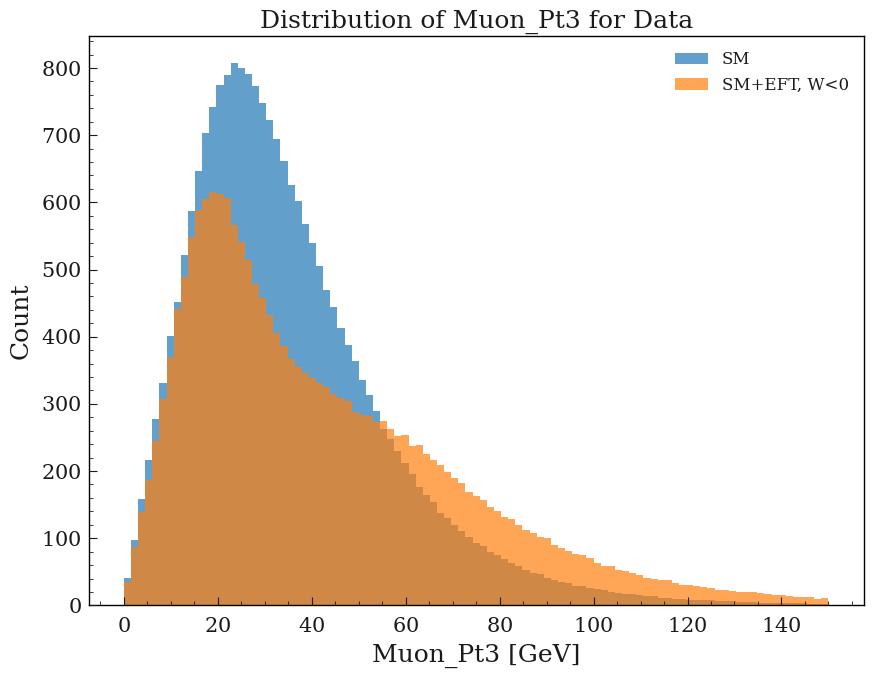

In [25]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax = fig.add_subplot(gs[:3, :2])

neg_mask = target_array[:,-1] < 0
pos_mask = ~neg_mask

bins = np.linspace(0, 150, 100)
ax.hist(source_array[:, keys.index('Muon_Pt3')], weights=source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_array[:, keys.index('Muon_Pt3')], weights=target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT, W<0");
ax.set_xlabel(r"Muon_Pt3 [GeV]")
ax.set_ylabel("Count")
ax.legend()
ax.set_title(r"Distribution of Muon_Pt3 for Data")

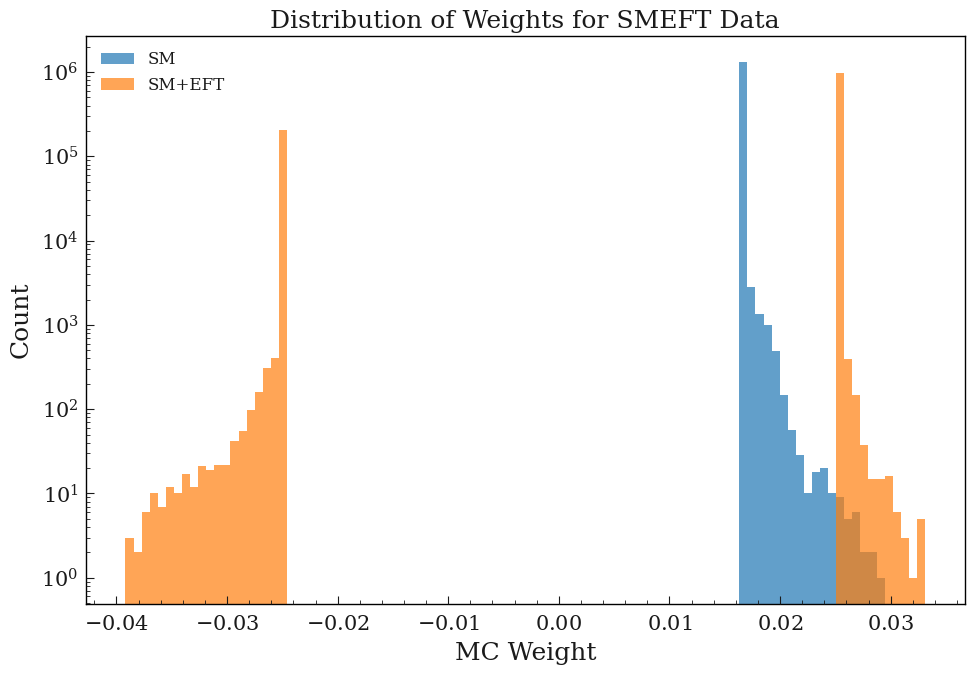

In [26]:
fig, ax = plt.subplots()
fig.set_size_inches(10,7)

bins = np.linspace(np.min((source_array[:,-1].min(), target_array[:,-1].min())),
                   np.max((source_array[:,-1].max(), target_array[:,-1].max())),
                   100)
ax.hist(source_array[:,-1], bins=bins,
        color='tab:blue', alpha=0.7, label=r"SM");
ax.hist(target_array[:,-1], bins=bins,
        color='tab:orange', alpha=0.7, label=r"SM+EFT");
ax.set_xlabel(r"MC Weight")
ax.set_ylabel("Count")
ax.set_yscale("log")
ax.legend()
ax.set_title(r"Distribution of Weights for SMEFT Data")
fig.tight_layout()
#fig.savefig("SMEFT_weights.pdf")

# Split into training/validation/testing datasets

In [27]:
# sample size and train/val/test splits
N = min([int(source_array.shape[0]), int(target_array.shape[0])])
training_cutoff = int(0.65 * N) # 65%
validation_cutoff = int(0.15 * N) # 15%
testing_cutoff = int(0.2 * N) # 20%
training_cutoff, validation_cutoff, testing_cutoff

(776369, 179162, 238883)

In [28]:
DATA_NUM = ""

if SAVE_DATA is True:
    np.random.shuffle(source_array)
    np.save(osp.splitext(source_path)[0] + "{}_train.npy".format(DATA_NUM), source_array[:training_cutoff])
    np.save(osp.splitext(source_path)[0] + "{}_val.npy".format(DATA_NUM), source_array[training_cutoff:training_cutoff+validation_cutoff])
    np.save(osp.splitext(source_path)[0] + "{}_test.npy".format(DATA_NUM), source_array[training_cutoff+validation_cutoff:training_cutoff+validation_cutoff+testing_cutoff])

In [29]:
if SAVE_DATA is True:
    np.random.shuffle(target_array)
    np.save(osp.splitext(target_path)[0] + "{}_train.npy".format(DATA_NUM), target_array[:training_cutoff])
    np.save(osp.splitext(target_path)[0] + "{}_val.npy".format(DATA_NUM), target_array[training_cutoff:training_cutoff+validation_cutoff])
    np.save(osp.splitext(target_path)[0] + "{}_test.npy".format(DATA_NUM), target_array[training_cutoff+validation_cutoff:training_cutoff+validation_cutoff+testing_cutoff])